# Interfacing Basics

In [1]:
from nqct.utils.QuantumSession import QuantumSession

api_key = input('Enter API Key') #<---PASTE_API_KEY_HERE instead of the input(...)
qs = QuantumSession(api_key=api_key, storage_path='temp/')
qs.list_backends();
#Copy over the desired backend from the given list
qs.select_backend('quantware_soprano_d2')

,Name,Backend ID,Qubits
0,Qiskit Aer Simulator,aer_simulator,5
1,QuantWare Soprano D2,quantware_soprano_d2,7


In [2]:
my_script = r"""
OPENQASM 3;
include 'stdgates_transmon_fixed_coupler.inc';
 
bit[3] c;
qubit[3] q;
 
z q[0];
rx(pi/2) q[0];
 
z q[1];
ry(pi/2) q[1];
 
ctrl @ z q[0], q[1];
 
z q[1];
ry(pi/2) q[1];
 
delay[0]  q;
c[0] = measure q[0];
c[1] = measure q[1];
c[2] = measure q[2];
"""
qs.set_qasm(my_script)
qs.get_qregs_in_qasm()

[('q', 0), ('q', 1), ('q', 2)]

In [3]:
qs.set_qreg_physical_mapping({('q',0):2, ('q',1):0, ('q',2):1})
qs.validate()

,qubits,qubitsAux,start_time,end_time,gate_type,col_intensity,operation,angle
0,2,-1,0.000000e+00,0.000000e+00,Z(π),0.000000,Z,3.141593e+00
1,2,-1,0.000000e+00,3.200000e-08,X(π/2),0.000000,X,1.570796e+00
2,0,-1,0.000000e+00,0.000000e+00,Z(π),0.071429,Z,3.141593e+00
3,0,-1,0.000000e+00,3.200000e-08,Y(π/2),0.071429,Y,1.570796e+00
4,1,-1,0.000000e+00,3.200000e-08,32 ns,0.142857,D,3.200000e-08
5,0,2,9.377134e-08,1.555427e-07,Z(π),0.214286,Z,3.141593e+00
6,2,-1,9.377134e-08,1.555427e-07,61.7713 ns,0.285714,D,6.177134e-08
7,0,-1,9.377134e-08,9.377134e-08,Z(π),0.357143,Z,3.141593e+00
8,0,-1,9.377134e-08,1.257713e-07,Y(π/2),0.357143,Y,1.570796e+00
9,0,-1,1.257713e-07,1.555427e-07,29.7713 ns,0.357143,D,2.977134e-08


In [4]:
qs.set_acquisition_type('DISCRIMINATION')
qs.set_averaging_type('SingleShotCounts')
qs.set_num_shots(1024)
qs.set_shot_repeat(1)

In [5]:
leRes = qs.run()

The returned data is stored locally here:

In [6]:
leRes.data_folder

PosixPath('temp/68680b78-b82f-4f16-8b1c-a54981059877')

The dataset will be sliced differently depending on the acquisition settings. Nonetheless, the slicing parameters can be queried as:

In [7]:
leRes.get_inner_slicing_vars()

['shot']

The datasets can be queried over an entire classical register or individually within a given register:

In [8]:
cur_arrs = leRes.get_data('c')

There are handy visualisation functions where one may plot 

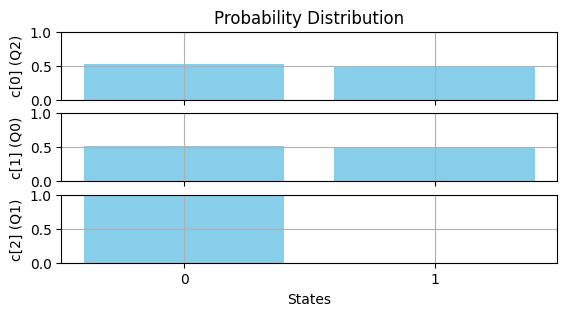

In [9]:
leRes.plot_histograms('c')

For a set of two qubits, it's often handy to see the correlated truth table. This can be readily plotted (using the registers 0 and 1 in this example), with the feature disabled if setting `plot_2D_histogram=False`:

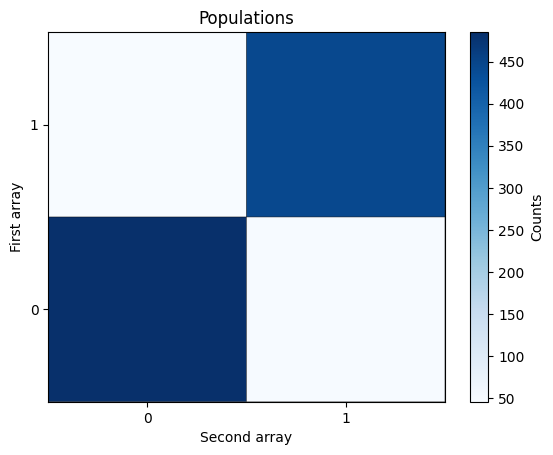

In [10]:
leRes.plot_histograms('c', [0,1])